In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

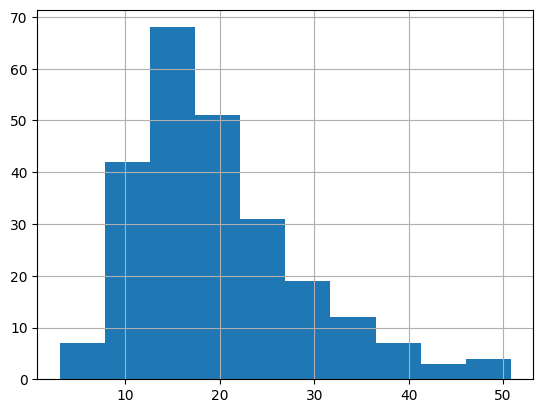

In [9]:
df["total_bill"].hist()

plt.show()

In [13]:
df.groupby("sex")["total_bill"].mean()

sex
Female    18.056897
Male      20.744076
Name: total_bill, dtype: float64

In [14]:
df.groupby("day")["total_bill"].sum()

day
Fri      325.88
Sat     1778.40
Sun     1627.16
Thur    1096.33
Name: total_bill, dtype: float64

In [15]:
df.groupby("smoker")["tip"].mean()

smoker
No     2.991854
Yes    3.008710
Name: tip, dtype: float64

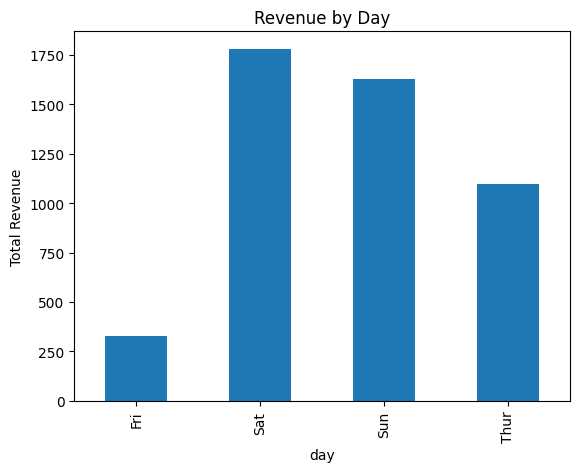

In [16]:
df.groupby("day")["total_bill"].sum().plot(kind="bar")
plt.title("Revenue by Day")
plt.ylabel("Total Revenue")
plt.show()

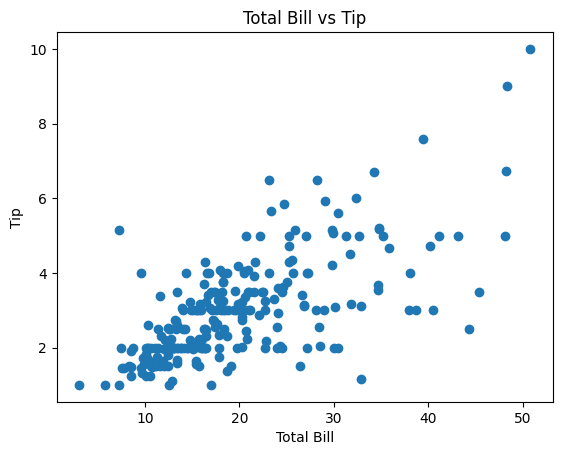

In [17]:
plt.scatter(df["total_bill"], df["tip"])

plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.title("Total Bill vs Tip")

plt.show()

In [18]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


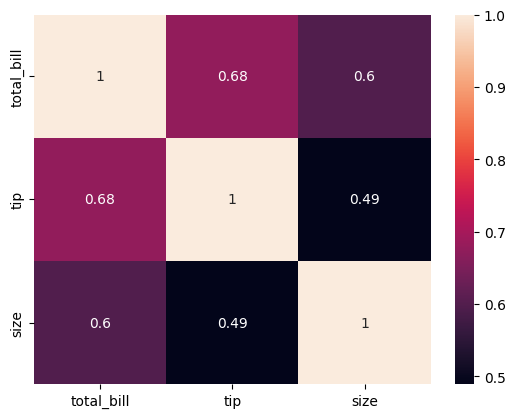

In [19]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

## SQL Business Queries

```sql
-- Find average bill amount
SELECT AVG(total_bill)
FROM tips;
```

```sql
-- Total revenue by day
SELECT day, SUM(total_bill) AS revenue
FROM tips
GROUP BY day
ORDER BY revenue DESC;
```

```sql
-- Average tip by smoker status
SELECT smoker, AVG(tip) AS average_tip
FROM tips
GROUP BY smoker;
```

# Dashboard Summary

The dashboard provides insights into customer billing behavior, tipping patterns, and revenue trends.

## Key Insights
- Higher bills generally result in higher tips
- Weekend days generate higher revenue
- Smoking status slightly impacts tipping behavior
- Revenue trends vary across weekdays

In [23]:
df.to_csv("eda_cleaned_tips.csv", index=False)